This will become a complete classical ML notebook using banana dataset.

✅ AdaBoost
✅ XGBoost
✅ CatBoost
✅ LightGBM

For each:

Classification Report

Colored Confusion Matrix

ROC–AUC Curve

In [ ]:
# Run this cell ONLY if not already installed

!pip install xgboost catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


Import important libraries for ML

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Models

from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

Load the dataset

In [ ]:
df = pd.read_csv('/content/banana_quality.csv')

df["Quality"] = df["Quality"].map({"Good":1, "Bad":0})

X = df.drop("Quality", axis=1)
y = df["Quality"]

Train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Scaling (needed for SVM & sometimes others)

In [ ]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

HELPER FUNCTION (VERY IMPORTANT — reuse for all models)

This prints:

Classification report

Colored confusion matrix

ROC curve

Evaluation Function

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):

    # Predict labels
    y_pred = model.predict(X_test)

    print(f"\n===== {model_name} =====")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix (colored)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # ROC Curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    plt.show()

Decision Tree


===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.94      0.93      0.94       781
           1       0.94      0.95      0.94       819

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600



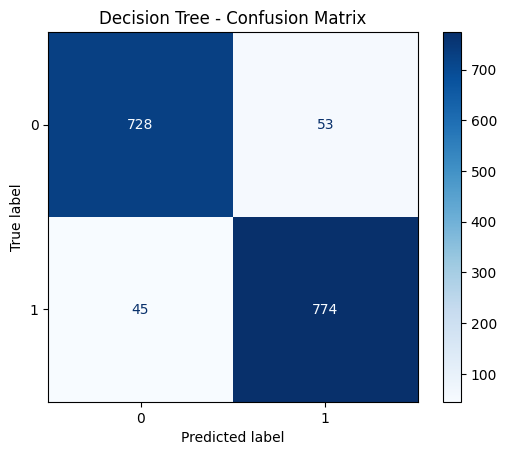

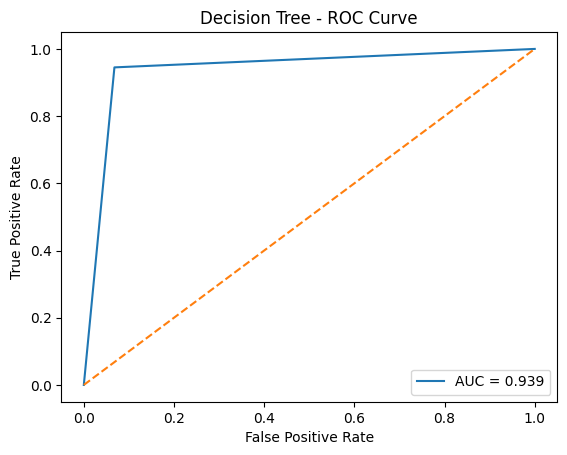

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

evaluate_model(dt, X_test, y_test, "Decision Tree")

Random Forest


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       781
           1       0.97      0.98      0.98       819

    accuracy                           0.97      1600
   macro avg       0.98      0.97      0.97      1600
weighted avg       0.98      0.97      0.97      1600



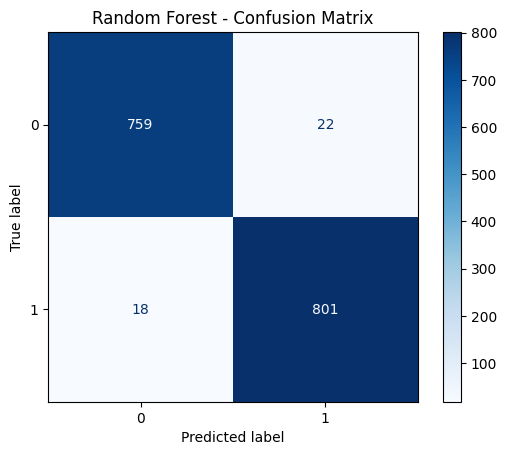

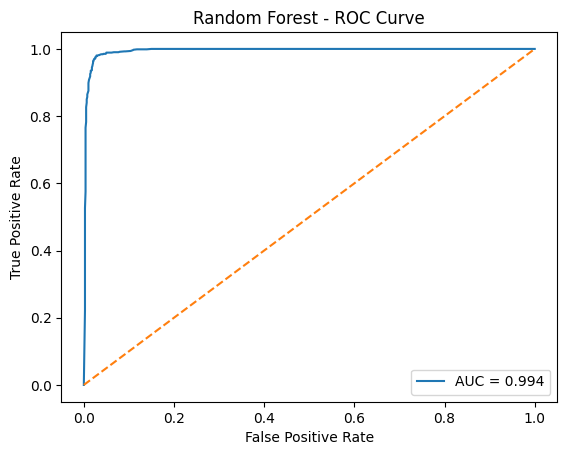

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

evaluate_model(rf, X_test, y_test, "Random Forest")

Naive Bayes


===== Naive Bayes =====
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       781
           1       0.88      0.91      0.90       819

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



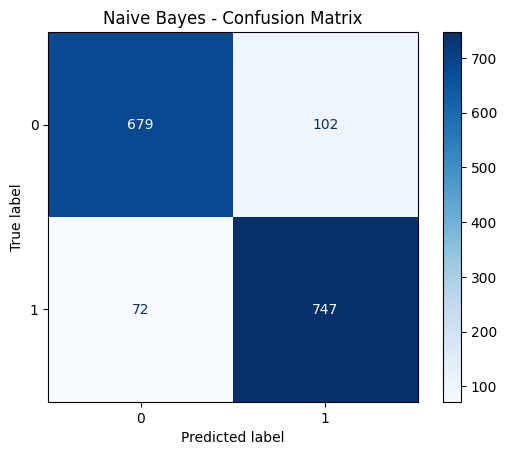

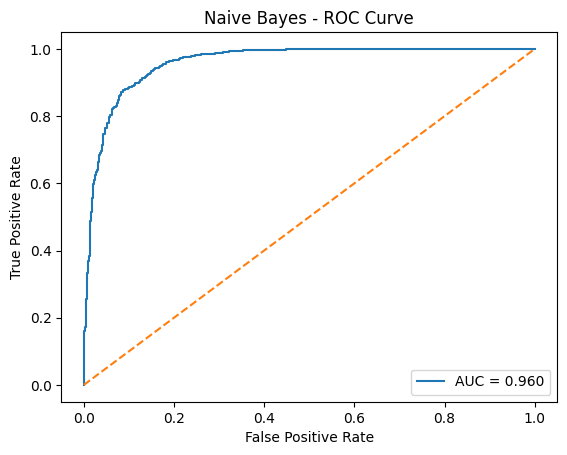

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)

evaluate_model(nb, X_test, y_test, "Naive Bayes")

SVM


===== SVM =====
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       781
           1       0.98      0.98      0.98       819

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



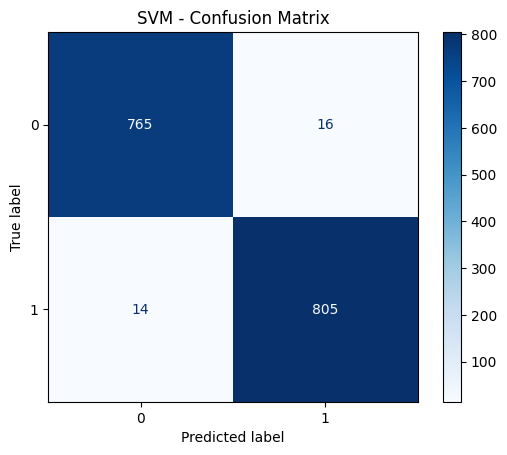

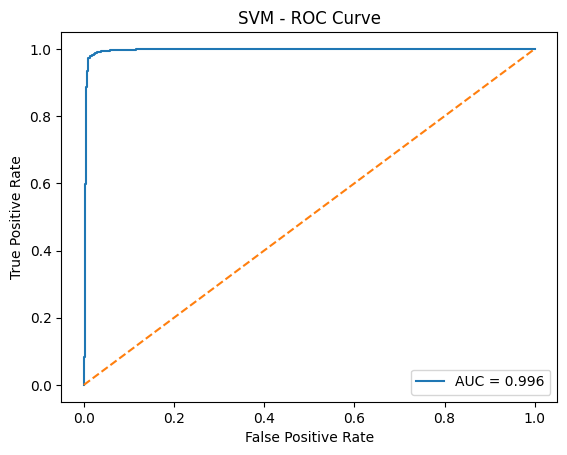

In [ ]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

evaluate_model(svm, X_test_scaled, y_test, "SVM")

ADABOOST


===== AdaBoost =====
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       781
           1       0.90      0.90      0.90       819

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



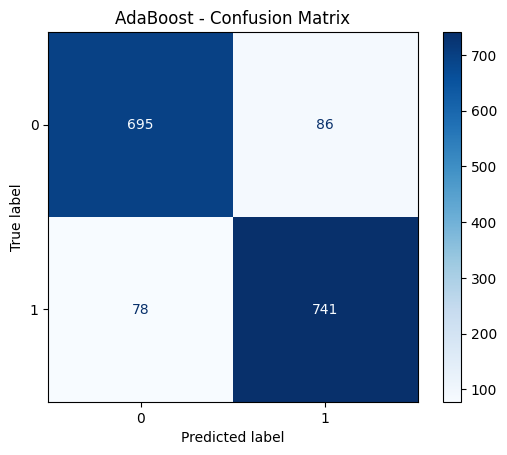

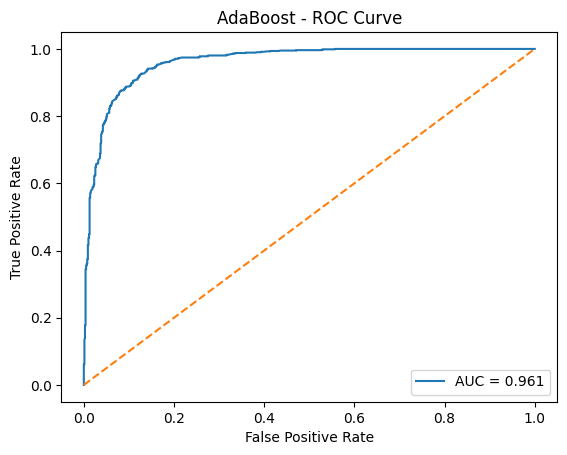

In [ ]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)

evaluate_model(ada, X_test, y_test, "AdaBoost")

XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:17:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



===== XGBoost =====
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       781
           1       0.98      0.98      0.98       819

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



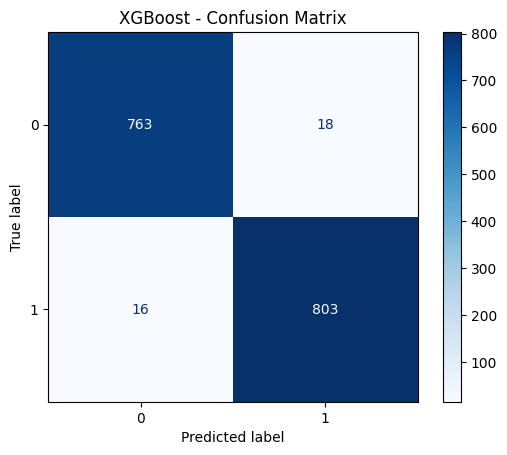

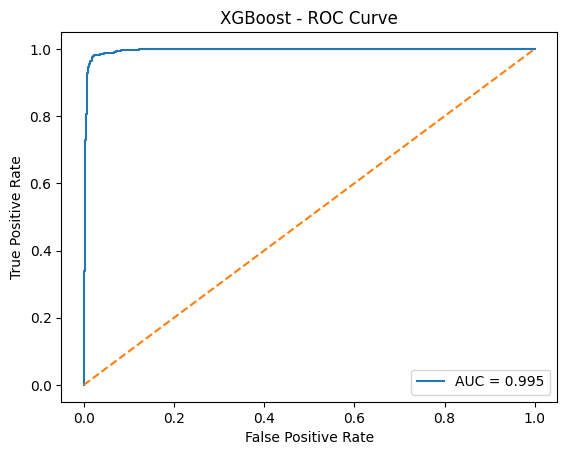

In [ ]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

evaluate_model(xgb, X_test, y_test, "XGBoost")

CatBoost


===== CatBoost =====
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       781
           1       0.98      0.98      0.98       819

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



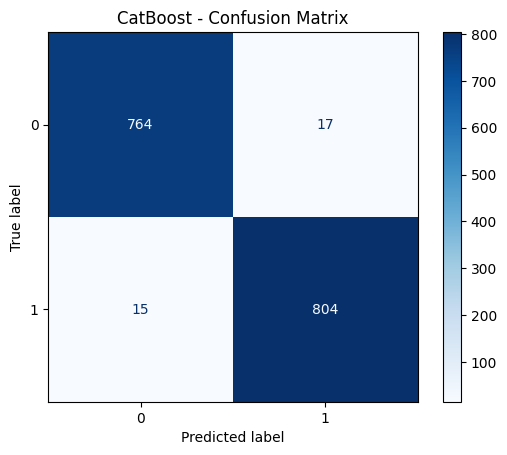

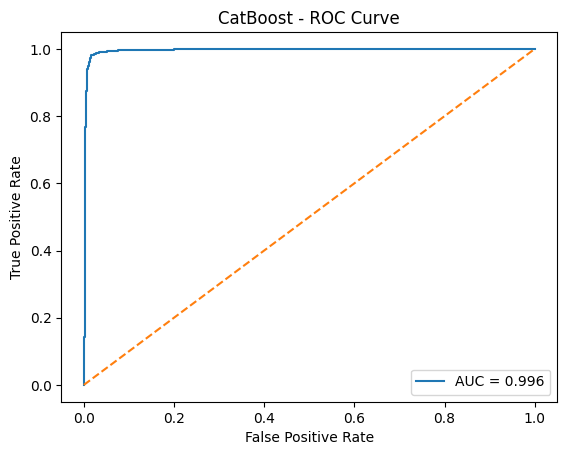

In [ ]:
cat = CatBoostClassifier(
    verbose=0,
    random_state=42
)

cat.fit(X_train, y_train)

evaluate_model(cat, X_test, y_test, "CatBoost")

Light GBM

In [3]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

In [4]:
df = pd.read_csv("/content/banana_quality.csv")

In [5]:
df.head()

,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity,Quality
0,-1.924968,0.468078,3.077832,-1.472177,0.294799,2.435570,0.271290,Good
1,-2.409751,0.486870,0.346921,-2.495099,-0.892213,2.067549,0.307325,Good
2,-0.357607,1.483176,1.568452,-2.645145,-0.647267,3.090643,1.427322,Good
3,-0.868524,1.566201,1.889605,-1.273761,-1.006278,1.873001,0.477862,Good
4,0.651825,1.319199,-0.022459,-1.209709,-1.430692,1.078345,2.812442,Good


In [6]:
map_quality = {"Good":0, "Bad":1}
df["Quality"]=df["Quality"].map(map_quality)
df.head()

,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity,Quality
0,-1.924968,0.468078,3.077832,-1.472177,0.294799,2.435570,0.271290,0
1,-2.409751,0.486870,0.346921,-2.495099,-0.892213,2.067549,0.307325,0
2,-0.357607,1.483176,1.568452,-2.645145,-0.647267,3.090643,1.427322,0
3,-0.868524,1.566201,1.889605,-1.273761,-1.006278,1.873001,0.477862,0
4,0.651825,1.319199,-0.022459,-1.209709,-1.430692,1.078345,2.812442,0


In [7]:
df.shape

(8000, 8)

In [8]:
y=df["Quality"]
X=df.drop("Quality", axis=1)

In [9]:
print(X.shape, y.shape)

(8000, 7) (8000,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) #train_test_split



In [11]:
# Create an instance of the classifier with default parameters
model = lgb.LGBMClassifier()

# Train the model
model.fit(X_train, y_train)



[LightGBM] [Info] Number of positive: 3020, number of negative: 2980
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000842 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 6000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503333 -> initscore=0.013334
[LightGBM] [Info] Start training from score 0.013334


LGBMClassifier()

In [12]:
# Make predictions
y_pred = model.predict(X_test)

print(y_pred[:5])
print(y_test[:5])

[1 0 0 1 0]
2215    1
2582    1
1662    0
3027    1
4343    0
Name: Quality, dtype: int64


In [14]:
# Evaluate the model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1026
           1       0.97      0.98      0.97       974

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



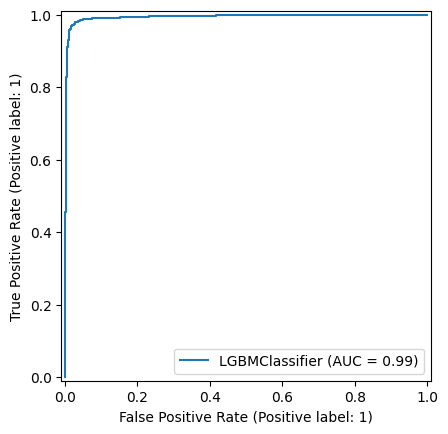

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# This plots the curve and calculates AUC automatically
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()
